# 03a — E1 Baseline CNN Training

**Experiment:** E1 — Baseline CNN trained on full FaceForensics++ frames  
**Purpose:** Establish a simple CNN baseline before transfer learning, face cropping, SBI, or frequency features.

This notebook contains **training only**. It does not evaluate the test set. Internal FaceForensics++ evaluation belongs in `04a_E1_FFPP_Evaluation.ipynb`.

The code was extracted from the master notebook without changing the original model architecture, preprocessing, optimizer, epoch count, or output filenames.

## Experimental design

- **Research question:** How well does a simple CNN trained from scratch detect real and fake FaceForensics++ frames?
- **Training input:** Full RGB frames from the clean video-level `dataset/train` split
- **Validation input:** Full RGB frames from the clean video-level `dataset/val` split
- **Image size:** 128 × 128
- **Transfer learning:** No
- **Optimizer:** Adam, learning rate 0.001
- **Loss:** Cross-entropy
- **Epochs:** 5
- **Seed:** 42
- **Checkpoint:** final epoch saved as `saved_models/baseline_cnn.pth`

This notebook is self-contained: it mounts Google Drive, validates the prepared data and records the complete training history. The test set is not accessed during training.

## 1. Training controls

The first complete clean rerun uses `RUN_TRAINING=True`. If the official E1 checkpoint already exists, training stops unless overwrite permission is explicitly enabled.

In [ ]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

SEED = 42
NUM_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_WORKERS = 0

CHECKPOINT_NAME = "baseline_cnn.pth"
RESULTS_NAME = "baseline_cnn_results.json"

print("E1 training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("Seed:", SEED)

E1 training enabled: True
Allow checkpoint overwrite: False
Seed: 42


## 2. Mount Drive, set reproducibility and validate paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import json
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TRAIN_DIR = os.path.join(BASE_PATH, "dataset", "train")
VAL_DIR = os.path.join(BASE_PATH, "dataset", "val")
MODEL_PATH = os.path.join(BASE_PATH, "saved_models", CHECKPOINT_NAME)
RESULTS_PATH = os.path.join(BASE_PATH, "results", RESULTS_NAME)
PLOT_PATH = os.path.join(BASE_PATH, "plots", "baseline_cnn_training.png")
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "ffpp_video_split_manifest.json")

for required_path, description in [
    (TRAIN_DIR, "Training directory"),
    (VAL_DIR, "Validation directory"),
    (SPLIT_MANIFEST_PATH, "Video-level split manifest"),
]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"{description} not found: {required_path}")

if RUN_TRAINING and os.path.exists(MODEL_PATH) and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"E1 checkpoint already exists: {MODEL_PATH}\n"
        "Set ALLOW_CHECKPOINT_OVERWRITE=True only when replacement is intentional."
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is unavailable; complete training will run more slowly on CPU.")
print("Training data:", TRAIN_DIR)
print("Validation data:", VAL_DIR)
print("Checkpoint:", MODEL_PATH)

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Training data: /content/drive/MyDrive/deepfake_project/dataset/train
Validation data: /content/drive/MyDrive/deepfake_project/dataset/val
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/baseline_cnn.pth


## 3. E1 preprocessing, dataset checks and data loaders

The transformation is unchanged from the original E1 experiment. Before training, the notebook verifies class mapping, balanced counts and source-video separation.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5],
    ),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

EXPECTED_CLASS_MAPPING = {"fake": 0, "real": 1}
if train_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(
        f"Unexpected training class mapping: {train_dataset.class_to_idx}"
    )
if val_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(
        f"Unexpected validation class mapping: {val_dataset.class_to_idx}"
    )


def named_class_counts(dataset):
    numeric_counts = Counter(dataset.targets)
    return {
        class_name: numeric_counts[class_index]
        for class_name, class_index in dataset.class_to_idx.items()
    }


train_class_counts = named_class_counts(train_dataset)
val_class_counts = named_class_counts(val_dataset)

if train_class_counts != {"fake": 1400, "real": 1400}:
    raise RuntimeError(f"Unexpected training counts: {train_class_counts}")
if val_class_counts != {"fake": 300, "real": 300}:
    raise RuntimeError(f"Unexpected validation counts: {val_class_counts}")


def recover_video_ids(dataset):
    identifiers = set()
    for image_path, _ in dataset.samples:
        stem = os.path.splitext(os.path.basename(image_path))[0]
        if "_frame_" not in stem:
            raise ValueError(f"Cannot recover source-video id from: {image_path}")
        identifiers.add(stem.rsplit("_frame_", 1)[0])
    return identifiers


train_video_ids = recover_video_ids(train_dataset)
val_video_ids = recover_video_ids(val_dataset)
train_val_overlap = train_video_ids & val_video_ids
if train_val_overlap:
    raise RuntimeError(
        f"Train/validation source-video overlap detected: {sorted(train_val_overlap)[:5]}"
    )

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Training class counts:", train_class_counts)
print("Validation class counts:", val_class_counts)
print("Training source videos:", len(train_video_ids))
print("Validation source videos:", len(val_video_ids))
print("Train/validation overlapping videos:", len(train_val_overlap))
print("PASS: E1 data validation completed.")

Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Training class counts: {'fake': 1400, 'real': 1400}
Validation class counts: {'fake': 300, 'real': 300}
Training source videos: 280
Validation source videos: 60
Train/validation overlapping videos: 0
PASS: E1 data validation completed.


## 4. E1 model definition

The original three-convolution baseline architecture is preserved. Model initialisation occurs only after seed configuration.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = BaselineCNN().to(DEVICE)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


## 5. Train, record history and save the final-epoch E1 checkpoint

The original experiment saved the final epoch rather than selecting a checkpoint on the test set. Best validation information is recorded for reporting, while `baseline_cnn.pth` remains the final-epoch model.

Epoch [1/5], Loss: 0.6972, Validation Accuracy: 40.67%
Epoch [2/5], Loss: 0.6897, Validation Accuracy: 50.50%
Epoch [3/5], Loss: 0.6617, Validation Accuracy: 54.33%
Epoch [4/5], Loss: 0.5783, Validation Accuracy: 53.33%
Epoch [5/5], Loss: 0.5209, Validation Accuracy: 51.33%
Final-epoch model saved to: /content/drive/MyDrive/deepfake_project/saved_models/baseline_cnn.pth
Results saved to: /content/drive/MyDrive/deepfake_project/results/baseline_cnn_results.json
Best validation epoch: 3
Best validation accuracy: 54.33%


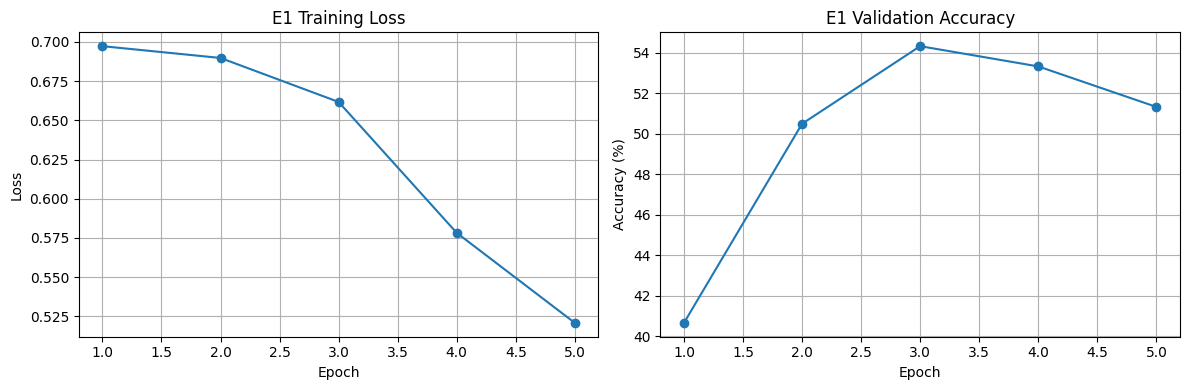

Training plot saved to: /content/drive/MyDrive/deepfake_project/plots/baseline_cnn_training.png


In [ ]:
if RUN_TRAINING:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_losses = []
    val_accuracies = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)
        train_losses.append(average_loss)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                outputs = model(images)
                predictions = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        validation_accuracy = 100.0 * correct / total
        val_accuracies.append(validation_accuracy)

        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}], "
            f"Loss: {average_loss:.4f}, "
            f"Validation Accuracy: {validation_accuracy:.2f}%"
        )

    best_epoch_index = int(np.argmax(val_accuracies))
    best_epoch = best_epoch_index + 1
    best_val_accuracy = val_accuracies[best_epoch_index]

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(PLOT_PATH), exist_ok=True)

    torch.save(model.state_dict(), MODEL_PATH)
    print("Final-epoch model saved to:", MODEL_PATH)

    results = {
        "experiment": "E1",
        "research_question": "Baseline performance of a shallow CNN trained from scratch",
        "model": "BaselineCNN",
        "checkpoint_strategy": "final epoch",
        "seed": SEED,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "image_size": [128, 128],
        "normalization_mean": [0.5, 0.5, 0.5],
        "normalization_std": [0.5, 0.5, 0.5],
        "class_mapping": train_dataset.class_to_idx,
        "training_class_counts": train_class_counts,
        "validation_class_counts": val_class_counts,
        "training_source_videos": len(train_video_ids),
        "validation_source_videos": len(val_video_ids),
        "train_validation_video_overlap": len(train_val_overlap),
        "training_losses": train_losses,
        "validation_accuracies": val_accuracies,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "final_val_accuracy": val_accuracies[-1],
        "final_training_loss": train_losses[-1],
        "checkpoint_path": MODEL_PATH,
        "split_manifest_path": SPLIT_MANIFEST_PATH,
    }

    with open(RESULTS_PATH, "w", encoding="utf-8") as file:
        json.dump(results, file, indent=4)

    print("Results saved to:", RESULTS_PATH)
    print("Best validation epoch:", best_epoch)
    print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

    epochs_axis = list(range(1, NUM_EPOCHS + 1))
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_axis, train_losses, marker="o")
    axes[0].set_title("E1 Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)

    axes[1].plot(epochs_axis, val_accuracies, marker="o")
    axes[1].set_title("E1 Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    print("Training plot saved to:", PLOT_PATH)
else:
    print("Training skipped safely.")

## 6. Next notebook

After training finishes and the checkpoint/result files exist, run `04a_E1_FFPP_Evaluation.ipynb` on the untouched clean video-level test split.

Do not select a checkpoint, threshold or hyperparameter using the test set.